In [78]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

In [196]:
processed = {}

# "customers" pre-processing

In [79]:
customers = pd.read_csv("./data/customers.csv")
customers_org = customers.copy()

print(customers.shape)
customers.head(3)

(1006, 17)


,customer_id,first_name,last_name,email,phone,date_of_birth,gender,address_line1,address_line2,city,state,postal_code,country,registration_date,is_premium,preferred_language,marketing_consent
0,1714a6e4-b887-4e06-83db-1e31a6633cd4,Danielle,Johnson,john21@example.net,001-581-896-0013x3890,1959-08-21,Other,402 Peterson Drives Apt. 511,Suite 155,Lindsaymouth,Ohio,16862.0,Uzbekistan,2024-06-09,False,Spanish,True
1,0a19457f-f26f-435e-aa85-a662920e58f7,Christian,Carter,barbara10@example.net,441.731.6475,1968-10-23,Other,419 Amanda Gardens,Apt. 764,Lake Mark,Wyoming,7832.0,Denmark,2025-05-19,False,English,True
2,1482080e-d1f6-43a7-9cb1-663c9dafcc1e,Antonio,Stewart,carl95@example.org,+1-876-772-4238x8496,1959-07-24,M,710 Eric Estate,Suite 916,Carlsonmouth,North Dakota,33454.0,Micronesia,2025-06-18,False,English,True


In [80]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1000 non-null   str    
 1   first_name          1000 non-null   str    
 2   last_name           1000 non-null   str    
 3   email               1000 non-null   str    
 4   phone               1000 non-null   str    
 5   date_of_birth       1000 non-null   str    
 6   gender              1000 non-null   str    
 7   address_line1       1000 non-null   str    
 8   address_line2       295 non-null    str    
 9   city                1000 non-null   str    
 10  state               1000 non-null   str    
 11  postal_code         1000 non-null   float64
 12  country             1000 non-null   str    
 13  registration_date   1000 non-null   str    
 14  is_premium          1000 non-null   object 
 15  preferred_language  1000 non-null   str    
 16  marketing_consent

In [81]:
customers['email'] = customers['email'].str.lower().str.strip()
customers['email']

0                john21@example.net
1             barbara10@example.net
2                carl95@example.org
3       maldonadoamanda@example.com
4              wcabrera@example.net
                   ...             
1001                            NaN
1002                            NaN
1003                            NaN
1004                            NaN
1005                            NaN
Name: email, Length: 1006, dtype: str

In [82]:
customers['date_of_birth'] = pd.to_datetime(customers['date_of_birth'])
customers['registration_date'] = pd.to_datetime(customers['registration_date'])

In [83]:
customers['age'] = (datetime.datetime.now() - customers['date_of_birth']).dt.days//365

In [84]:
customers['age'] .value_counts().sort_index()

age
18.0     7
19.0    22
20.0    10
21.0    13
22.0    14
        ..
77.0    17
78.0    20
79.0    24
80.0    24
81.0    15
Name: count, Length: 64, dtype: int64

In [85]:
customers['age_group'] = pd.cut(customers['age'],
                          bins = np.linspace(0, 100, 6), #[  0.,  20.,  40.,  60.,  80., 100.]
                          labels = ['below 20', '21-40', '41-60', '61-80', '80+'])

array([  0.,  20.,  40.,  60.,  80., 100.])

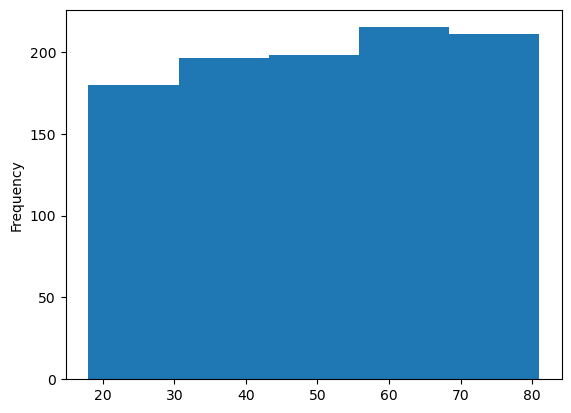

In [138]:
customers['age'].plot.hist(bins = 5)
np.linspace(0, 100, 6)

<Axes: xlabel='age_group'>

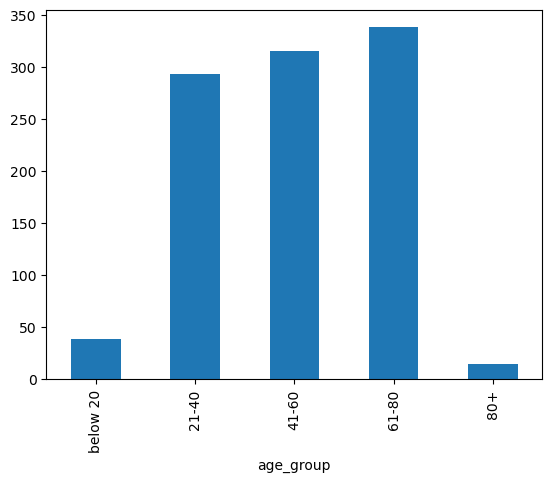

In [142]:
customers['age_group'].value_counts().sort_index().plot.bar()

In [197]:
processed['cleaned_customers'] = customers
customers.shape

(1006, 19)

In [73]:
print(f"\"Customers\" pre-processing completed with shape: {customers.shape}\n")

"Customers" pre-processing completed with shape: (1006, 19)



In [74]:
float('inf')

inf

# "products" pre-processing

In [198]:
products = pd.read_csv("./data/products.csv")
print(products.shape)
print(print(products.info()))
products.head(3)

(500, 19)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      500 non-null    str    
 1   product_name    500 non-null    str    
 2   description     500 non-null    str    
 3   category        500 non-null    str    
 4   subcategory     500 non-null    str    
 5   brand           500 non-null    str    
 6   price           500 non-null    float64
 7   cost            500 non-null    float64
 8   weight_kg       500 non-null    float64
 9   dimensions_cm   500 non-null    str    
 10  color           500 non-null    str    
 11  material        500 non-null    str    
 12  stock_quantity  500 non-null    int64  
 13  is_active       500 non-null    bool   
 14  created_date    500 non-null    str    
 15  last_updated    500 non-null    str    
 16  supplier_id     500 non-null    str    
 17  rating_avg      500 non-null    floa

,product_id,product_name,description,category,subcategory,brand,price,cost,weight_kg,dimensions_cm,color,material,stock_quantity,is_active,created_date,last_updated,supplier_id,rating_avg,review_count
0,8422dcb8-bfec-4842-962e-7e1c3f1967ad,User-centric client-server installation Jeans,Every still fire just similar there movement. ...,Clothing,Jeans,"Kennedy, Burns and King",138.10,87.82,7.49,48x15x65,Black,Fabric,408,True,2025-06-17,2025-08-03,f2cd5a20-75dd-475e-843b-f4632fd20706,2.59,444
1,4b1b74ad-a7a2-4c13-a656-b9a00d77bc72,Re-contextualized human-resource firmware Furn...,Almost interview southern any across. Mother m...,Home & Kitchen,Furniture,"Dickerson, Olsen and Thomas",245.65,112.86,19.83,78x30x76,Blue,Metal,73,True,2025-04-21,2025-08-02,4034f9cd-89e4-4f31-bb58-b4b4569c475e,2.72,701
2,ecb6278a-763c-4c62-8cd9-e94f5ac92716,Persistent 4thgeneration intranet T-Shirts,However carry protect throughout. Religious fa...,Clothing,T-Shirts,"Hunter, Wilson and West",206.45,108.81,17.48,46x49x81,Black,Ceramic,312,True,2024-11-01,2025-07-26,ac0aedae-8011-4956-a164-7bc07d1768ce,2.40,841


[   5.66    499.7175  993.775  1487.8325 1981.89  ]


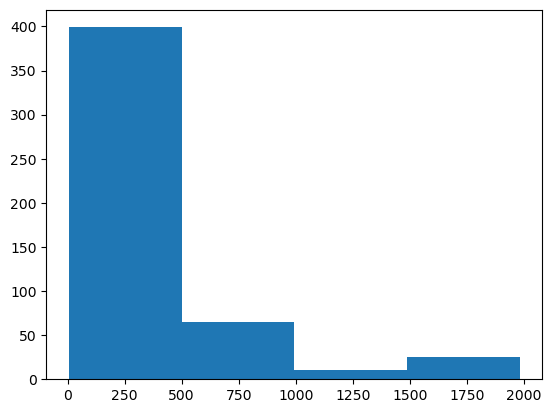

In [199]:
# products['price'].plot.hist(bins = 4)

counts, bins, patches = plt.hist(products['price'], bins=4)
print(bins)
plt.show()

In [200]:
# pre-processing product name
products['product_name'] = products['product_name'].str.strip()

# Converting "created_date" and "last_updated" to the datatype - datetime
products['created_date'] = pd.to_datetime(products['created_date'])
products['last_updated'] = pd.to_datetime(products['last_updated'])


# Converting products['price'] to numeric (seems redundant to me)
products['price'] = pd.to_numeric(products['price'], errors = 'coerce')

# Creating price groups
products['price_category'] = pd.cut(products['price'],
                                    bins = np.linspace(np.min(products['price']),np.max(products['price']), 5),
                                   labels = ['Budget', 'Medium', 'Premium', 'Luxuary'])

# Storing the cleaned_products into processed dictionary
processed['cleaned_products'] = products

print(f"\"Products\" pre-processing completed with shape: {products.shape}\n")

"Products" pre-processing completed with shape: (500, 20)



In [203]:
processed['cleaned_products'].info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_id      500 non-null    str           
 1   product_name    500 non-null    str           
 2   description     500 non-null    str           
 3   category        500 non-null    str           
 4   subcategory     500 non-null    str           
 5   brand           500 non-null    str           
 6   price           500 non-null    float64       
 7   cost            500 non-null    float64       
 8   weight_kg       500 non-null    float64       
 9   dimensions_cm   500 non-null    str           
 10  color           500 non-null    str           
 11  material        500 non-null    str           
 12  stock_quantity  500 non-null    int64         
 13  is_active       500 non-null    bool          
 14  created_date    500 non-null    datetime64[us]
 15  last_updated    5

In [201]:
print(processed.keys())
processed['cleaned_products'].head(1)

dict_keys(['cleaned_customers', 'cleaned_products'])


,product_id,product_name,description,category,subcategory,brand,price,cost,weight_kg,dimensions_cm,color,material,stock_quantity,is_active,created_date,last_updated,supplier_id,rating_avg,review_count,price_category
0,8422dcb8-bfec-4842-962e-7e1c3f1967ad,User-centric client-server installation Jeans,Every still fire just similar there movement. ...,Clothing,Jeans,"Kennedy, Burns and King",138.1,87.82,7.49,48x15x65,Black,Fabric,408,True,2025-06-17,2025-08-03,f2cd5a20-75dd-475e-843b-f4632fd20706,2.59,444,Budget


<Axes: xlabel='price_category'>

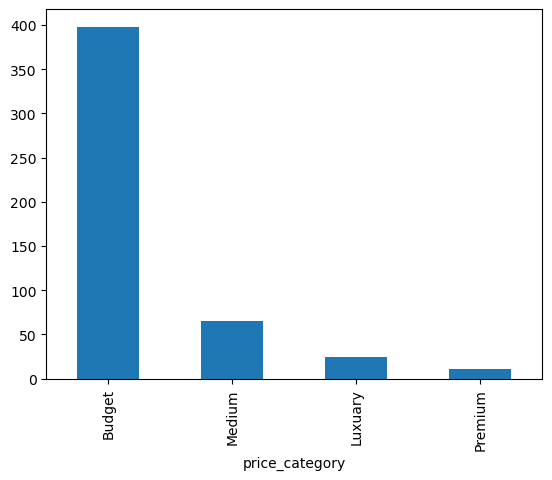

In [202]:
processed['cleaned_products']['price_category'].value_counts().plot.bar()

# "orders" pre-processing

In [239]:
orders = pd.read_csv("./data/orders.csv")
print(orders.info())
orders.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  2000 non-null   str    
 1   customer_id               2000 non-null   str    
 2   order_date                2000 non-null   str    
 3   order_status              2000 non-null   str    
 4   payment_method            2000 non-null   str    
 5   shipping_method           2000 non-null   str    
 6   shipping_address_line1    2000 non-null   str    
 7   shipping_address_line2    577 non-null    str    
 8   shipping_city             2000 non-null   str    
 9   shipping_state            2000 non-null   str    
 10  shipping_postal_code      2000 non-null   int64  
 11  shipping_country          2000 non-null   str    
 12  billing_same_as_shipping  2000 non-null   bool   
 13  discount_amount           2000 non-null   float64
 14  tax_amount         

,order_id,customer_id,order_date,order_status,payment_method,shipping_method,shipping_address_line1,shipping_address_line2,shipping_city,shipping_state,...,shipping_country,billing_same_as_shipping,discount_amount,tax_amount,shipping_cost,total_amount,notes,created_at,updated_at,subtotal
0,5f815692-8496-4d2d-a1d6-8ccb4353f5f5,d4020c91-b1b2-4d80-8024-c88469bc488b,2025-08-02,processing,paypal,pickup,726 David Freeway Suite 021,NaN,Jasonview,Minnesota,...,Tonga,True,0.00,4.19,14.50,68.04,NaN,2025-08-02 00:59:34,2025-08-10 19:11:06,49.35
1,ae61fecc-8b06-42a8-a528-45497b170f5f,c3384516-27af-4a1b-b450-4ef91e69b76f,2024-12-23,shipped,bank_transfer,overnight,3131 David Unions Apt. 243,NaN,Jeanettefurt,Missouri,...,Iceland,False,47.25,5.50,22.06,45.03,NaN,2024-12-23 20:57:45,2025-08-14 19:43:43,64.72
2,02745c51-212e-4bc5-aa45-ea6be8cdd48a,f0f5f1f4-d061-4a0a-bebc-9aaf6704eef3,2024-10-01,delivered,cash_on_delivery,overnight,621 Perez Harbor,Suite 060,Port Staceychester,Washington,...,Qatar,True,13.69,233.13,10.97,2973.07,NaN,2024-10-01 00:29:15,2024-10-04 15:11:06,2742.66


In [250]:
# Converting the data type of "date" to datetime
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Converting "total_amount" to numeric (seems redundant to me)
orders["total_amount"] = pd.to_numeric(orders["total_amount"])

# Extracting month and year for seasonal analysis
orders["order_year"] = orders["order_date"].dt.year
orders["order_month"] = orders["order_date"].dt.month

processed['cleaned_orders'] = orders
print(f"\"Orders\" pre-processing completed with shape: {orders.shape}\n")

"Orders" pre-processing completed with shape: (2000, 23)



# "order_items" pre-processing

In [253]:
order_items = pd.read_csv("./data/order_items.csv")
print(order_items.info())
order_items.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 6022 entries, 0 to 6021
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_item_id     6022 non-null   str    
 1   order_id          6022 non-null   str    
 2   product_id        6022 non-null   str    
 3   quantity          6022 non-null   int64  
 4   unit_price        6022 non-null   float64
 5   discount_applied  6022 non-null   bool   
 6   discount_amount   6022 non-null   float64
dtypes: bool(1), float64(2), int64(1), str(3)
memory usage: 288.3 KB
None


,order_item_id,order_id,product_id,quantity,unit_price,discount_applied,discount_amount
0,f62ac7a8-b028-4234-90e1-cca469d2d7a5,5f815692-8496-4d2d-a1d6-8ccb4353f5f5,de8236c9-ad71-45a5-99b4-18445c15801d,3,16.45,False,0.0
1,43232f2e-07fa-4e97-80a1-e9578d3fb28e,ae61fecc-8b06-42a8-a528-45497b170f5f,915f0730-59a6-4e76-8133-211ecf3b9033,2,32.36,False,0.0
2,f9b6131c-52ba-422c-8055-6082feb966ea,02745c51-212e-4bc5-aa45-ea6be8cdd48a,84818689-9ac1-4ae6-8275-586880502bd1,2,568.21,False,0.0


In [262]:
# Converting numerical columns (seems redundant to me)
order_items['quantity'] = pd.to_numeric(order_items['quantity'],  errors = 'coerce')
order_items['unit_price'] = pd.to_numeric(order_items['unit_price'],  errors = 'coerce')
order_items['discount_amount'] = pd.to_numeric(order_items['discount_amount'],  errors = 'coerce')

# Calculating total price of each item
order_items['total_price'] = order_items['unit_price'] * order_items['quantity']
processed['cleaned_order_items'] = order_items
print(f"\"Order_items\" pre-processing completed with shape: {order_items.shape}\n")

"Order_items" pre-processing completed with shape: (6022, 8)



# "reviews" pre-processing

In [264]:
reviews = pd.read_csv("./data/reviews.csv")
reviews.head(3)

,review_id,product_id,customer_id,order_id,rating,title,review_text,is_verified_purchase,helpful_votes,total_votes,review_date,is_deleted
0,4e9b9142-ea4c-4caa-bd71-3b24c1270623,62d664c8-8e85-42fc-bf31-ea6403db3ede,964a4dc3-be5f-4bd9-9ef2-aaf951e3ce40,de03a512-b85f-4100-a996-caca8ca984ed,3,Everyone specific big thousand three else form...,Hand officer behavior discover special. Attack...,True,24,59,2025-07-19,False
1,fbfab025-b391-447d-a18b-4920afa677f3,1ef2fcbf-53be-430f-9f56-dcf7cbcccf20,964a4dc3-be5f-4bd9-9ef2-aaf951e3ce40,de03a512-b85f-4100-a996-caca8ca984ed,2,Use dog range begin police blue prevent.,Culture off impact mean condition. Prevent my ...,True,46,47,2025-07-23,False
2,a2e67e41-0162-4f22-9d62-80d5c5cdc0f6,205f1971-6089-4be1-a77a-3740515a8902,964a4dc3-be5f-4bd9-9ef2-aaf951e3ce40,de03a512-b85f-4100-a996-caca8ca984ed,4,Second free as head specific win key.,Could under political look. Step media parent ...,True,24,3,2025-04-04,False


In [277]:
# Converting 'review_date' to datetime
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

# Convert 'rating' to numeric
reviews['rating'] = pd.to_numeric(reviews['rating'], errors = 'coerce')


# Converting 'rating' to categories
reviews['rating_category'] = reviews['rating'].apply(lambda x: 'Excellent' if x >= 4.5 else
                                                    'Good' if x >= 3.5 else
                                                    'Average' if x >= 2.5 else
                                                    'Poor')

processed['cleaned_reviews'] = reviews
print(f'Processed reviews: {reviews.shape} records')

Processed reviews: (1523, 13) records


<Axes: xlabel='rating_category'>

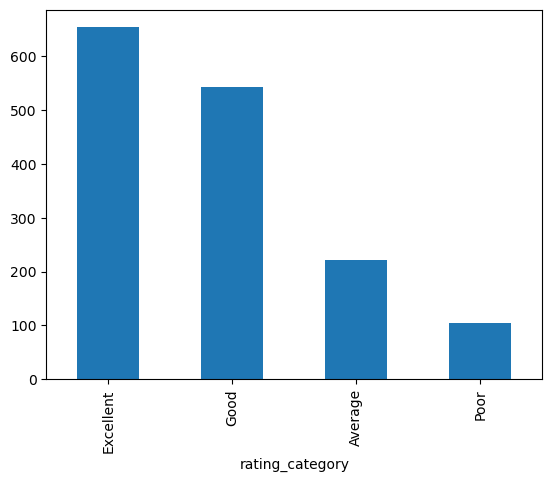

In [274]:
reviews['rating_category'].value_counts().plot.bar()

In [279]:
processed.keys()

dict_keys(['cleaned_customers', 'cleaned_products', 'cleaned_orders', 'cleaned_order_items', 'cleaned_reviews'])

In [281]:
processed['cleaned_reviews'].head(3)

,review_id,product_id,customer_id,order_id,rating,title,review_text,is_verified_purchase,helpful_votes,total_votes,review_date,is_deleted,rating_category
0,4e9b9142-ea4c-4caa-bd71-3b24c1270623,62d664c8-8e85-42fc-bf31-ea6403db3ede,964a4dc3-be5f-4bd9-9ef2-aaf951e3ce40,de03a512-b85f-4100-a996-caca8ca984ed,3,Everyone specific big thousand three else form...,Hand officer behavior discover special. Attack...,True,24,59,2025-07-19,False,Average
1,fbfab025-b391-447d-a18b-4920afa677f3,1ef2fcbf-53be-430f-9f56-dcf7cbcccf20,964a4dc3-be5f-4bd9-9ef2-aaf951e3ce40,de03a512-b85f-4100-a996-caca8ca984ed,2,Use dog range begin police blue prevent.,Culture off impact mean condition. Prevent my ...,True,46,47,2025-07-23,False,Poor
2,a2e67e41-0162-4f22-9d62-80d5c5cdc0f6,205f1971-6089-4be1-a77a-3740515a8902,964a4dc3-be5f-4bd9-9ef2-aaf951e3ce40,de03a512-b85f-4100-a996-caca8ca984ed,4,Second free as head specific win key.,Could under political look. Step media parent ...,True,24,3,2025-04-04,False,Good


# Business Metric
## customer_metrics

In [236]:
customer_metrics = orders.groupby('customer_id').agg({'total_amount' : ['sum', 'count', 'mean'],
                                                      'order_date' : ['min', 'max']}).round(2)

customer_metrics

total_amount                 order_date  \
                                              sum count     mean         min   
customer_id                                                                    
00377c6d-2b32-443f-a7f7-425fc7857cce      3609.87     3  1203.29  2024-11-25   
00593181-4820-451c-9c0a-a135dd30187e      6756.62     3  2252.21  2024-11-19   
006b6f02-dfbd-4523-83ee-eb82bd87c7e9      1426.50     2   713.25  2024-11-15   
00736676-d332-430d-a818-b5294988715e      2704.74     2  1352.37  2024-08-24   
007f4229-bc23-4f91-afb6-6f7eb310be22      2396.14     4   599.04  2024-10-25   
...                                           ...   ...      ...         ...   
fd0ff19d-7f8a-44ba-87d7-5fd8928f205a      3479.40     1  3479.40  2025-04-24   
fd363c38-7287-4937-8269-078e8579bb9c        48.64     1    48.64  2025-05-11   
fe13ac07-72d5-4c34-a43c-6223f9237982      2822.93     1  2822.93  2024-10-25   
fe8dc41e-d9db-47ae-8d7e-7ee02788bc0e     15550.27     7  2221.47  2024-09-02   
ff8c902a-d46f-456d-9adf-d12b67c79373      3847.21     3  1282.40  2024-12-01   

                                                  
                                             max  
customer_id                                       
00377c6d-2b32-443f-a7f7-425fc7857cce  2025-07-11  
00593181-4820-451c-9c0a-a135dd30187e  2025-06-12  
006b6f02-dfbd-4523-83ee-eb82bd87c7e9  2025-04-29  
00736676-d332-430d-a818-b5294988715e  2024-11-12  
007f4229-bc23-4f91-afb6-6f7eb310be22  2025-07-01  
...                                          ...  
fd0ff19d-7f8a-44ba-87d7-5fd8928f205a  2025-04-24  
fd363c38-7287-4937-8269-078e8579bb9c  2025-05-11  
fe13ac07-72d5-4c34-a43c-6223f9237982  2024-10-25  
fe8dc41e-d9db-47ae-8d7e-7ee02788bc0e  2025-01-11  
ff8c902a-d46f-456d-9adf-d12b67c79373  2025-07-17  

[852 rows x 5 columns]

In [237]:
customer_metrics.columns

MultiIndex([('total_amount',   'sum'),
            ('total_amount', 'count'),
            ('total_amount',  'mean'),
            (  'order_date',   'min'),
            (  'order_date',   'max')],
           )

In [238]:
customer_metrics.columns = ['total_amount', 'order_counts', 'mean_order_values', 'first_order_date', 'last_order_date']
customer_metrics = customer_metrics.reset_index()
customer_metrics = customer_metrics.merge(customers[['customer_id', 'age_group']])
customer_metrics

,customer_id,total_amount,order_counts,mean_order_values,first_order_date,last_order_date,age_group
0,00377c6d-2b32-443f-a7f7-425fc7857cce,3609.87,3,1203.29,2024-11-25,2025-07-11,41-60
1,00593181-4820-451c-9c0a-a135dd30187e,6756.62,3,2252.21,2024-11-19,2025-06-12,41-60
2,006b6f02-dfbd-4523-83ee-eb82bd87c7e9,1426.50,2,713.25,2024-11-15,2025-04-29,61-80
3,00736676-d332-430d-a818-b5294988715e,2704.74,2,1352.37,2024-08-24,2024-11-12,80+
4,007f4229-bc23-4f91-afb6-6f7eb310be22,2396.14,4,599.04,2024-10-25,2025-07-01,41-60
...,...,...,...,...,...,...,...
847,fd0ff19d-7f8a-44ba-87d7-5fd8928f205a,3479.40,1,3479.40,2025-04-24,2025-04-24,21-40
848,fd363c38-7287-4937-8269-078e8579bb9c,48.64,1,48.64,2025-05-11,2025-05-11,41-60
849,fe13ac07-72d5-4c34-a43c-6223f9237982,2822.93,1,2822.93,2024-10-25,2024-10-25,61-80
850,fe8dc41e-d9db-47ae-8d7e-7ee02788bc0e,15550.27,7,2221.47,2024-09-02,2025-01-11,41-60
